Workflow DAG:
  [0] Fileset -> Fileset builder=<function get_fileset at 0x7f1ed9d3f880>
  [1] SingleMuonAnalysis -> Analysis builder=<function run_analysis at 0x7f1ed9d3fc40>
  [2] PlottingMuonAnalysis -> Plotting builder=<function plot_results at 0x7f1ed9d3fce0>
Edges:
  Fileset -> SingleMuonAnalysis
  SingleMuonAnalysis -> PlottingMuonAnalysis
Executing step 'Fileset' of type 'Fileset' with the user code <function get_fileset at 0x7f1ed9d3f880>
Extracted from cache: cache_hist/Fileset/308ad2089fe7984aed2aa4ecc8b94f514c652884af87b3acccf3ba7eec3fb944
  -> materialized at cache_hist/Fileset/308ad2089fe7984aed2aa4ecc8b94f514c652884af87b3acccf3ba7eec3fb944
Executing step 'SingleMuonAnalysis' of type 'Analysis' with the user code <function run_analysis at 0x7f1ed9d3fc40>
Extracted from cache: cache_hist/Chunking/c02450435a2fea254deb326f08c86b859076c077813bfbab50635136cb795029

Split strategy applied, starting independent processing of 5 fileset subsets...

---------------------------------

Output()

loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 490, in _process_worker
    r = call_item()
        ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/loky/process_executor.py", line 291, in __call__
    return self.fn(*self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1192, in automatic_retries
    raise e
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1176, in automatic_retries
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py", line 1256, in metadata_fetcher_root
    with uproot.open(
         ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/site-packages/uproot/reading.py", line 144, in open
    file = ReadOnlyFile(
           ^^^^^^

Failure caught!
------------------------------------
Processing fileset_chunk_1.json
Extracted from cache: cache_hist/ChunkAnalysis/a3eaaad248943c6c036c1f03a0ca22ee9c8de2398562e00e394512201c13c293
Successfully processed!
------------------------------------
Processing fileset_chunk_2.json
conn: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': 'eff19f3dbbbe40a992b31f60b500bb37', 'token': 'test'}
Reconnected to histserv: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': 'eff19f3dbbbe40a992b31f60b500bb37', 'token': 'test'}


Output()

...

Output()

Successfully processed!
------------------------------------
Processing fileset_chunk_4.json
conn: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': 'eff19f3dbbbe40a992b31f60b500bb37', 'token': 'test'}
Reconnected to histserv: {'address': 'histserv.cmsaf-dev.flatiron.hollandhpc.org:8788', 'hist_id': 'eff19f3dbbbe40a992b31f60b500bb37', 'token': 'test'}


Output()

Output()

Successfully processed!
  -> materialized at cache_hist/Analysis/ba9d6622a93c8ff44af9d47263e2d51724186dcfb7532204872c1a874b04eb93
Executing step 'PlottingMuonAnalysis' of type 'Plotting' with the user code <function plot_results at 0x7f1ed9d3fce0>


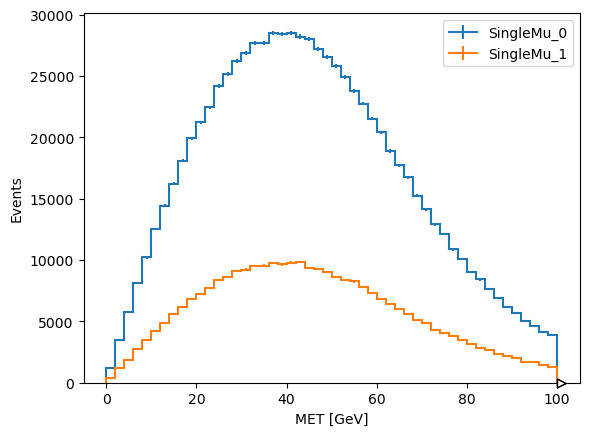

  -> materialized at cache_hist/Plotting/4fc626a74e22d4eae15ce535de495d2f191b28272fee9a50f0ec85eb617bae79

=== Run Summary ===
  ✓  Fileset                        Fileset
  !  SingleMuonAnalysis             Analysis             4/5 chunks OK
       FAILED fileset_chunk_0.json: Err(OSError('Failed to submit <bound method File.open of <XRootD.client.file.File object at 0x7fe84f242600>> request: [FATAL] Invalid address'))
  ✓  PlottingMuonAnalysis           Plotting



In [3]:
import histserv
from workflow import Step, Workflow, Fileset, Analysis, Plotting, RunConfig, render
from analysis_hist import get_fileset, run_analysis, plot_results, hist_template

# hist_client = histserv.Client(address="[::]:50051") # local
hist_client = histserv.Client(address="histserv.cmsaf-dev.flatiron.hollandhpc.org:8788") # coffea-casa
histserv_connection_info = hist_client.init(hist=hist_template(), token="test").get_connection_info()
# print(histserv_connection_info)


step_fileset = Step(
                    name="Fileset",
                    step_type=Fileset,
                    builder=get_fileset,
                )

step_analysis = Step(
                        name="SingleMuonAnalysis",
                        step_type=Analysis,
                        builder=run_analysis,
                        # add params
                    
                    )

step_plotting = Step(
                    name="PlottingMuonAnalysis",
                    step_type=Plotting,
                    builder=plot_results,
                )

workflow = Workflow()
workflow.add(step_fileset)
workflow.add(step_analysis, depends_on=[step_fileset])
workflow.add(step_plotting, depends_on=[step_analysis])

# To reconnect to an existing histogram on a subsequent run, read
# connection_info from the previous result and pass it here:
#   conn = result["results"]["SingleMuonAnalysis"]["merged"]
#   config = RunConfig(hist_client=hist_client, histserv_connection_info=conn, ...)

config = RunConfig(
                   hist_client=hist_client, 
                   histserv_connection_info=histserv_connection_info, 
                   percentage=20, 
                   cache_dir="cache_hist",
                   # chunk_fraction=0.3 
                  )

result = render(workflow, config)

In [4]:
result

{'paths': {'Fileset': PosixPath('cache_hist/Fileset/308ad2089fe7984aed2aa4ecc8b94f514c652884af87b3acccf3ba7eec3fb944'),
  'SingleMuonAnalysis': PosixPath('cache_hist/Analysis/ba9d6622a93c8ff44af9d47263e2d51724186dcfb7532204872c1a874b04eb93'),
  'PlottingMuonAnalysis': PosixPath('cache_hist/Plotting/4fc626a74e22d4eae15ce535de495d2f191b28272fee9a50f0ec85eb617bae79')},
 'results': {'Fileset': {'SingleMu_0': {'files': {'root://eeeeeeospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A41320F6-C9F9-574C-8DD2-BD98C200E4EE.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToWWTo2L2Nu_M125_TuneCP5_13TeV_powheg2_JHUGenV714_pythia8/NANOAODSIM/106X_mcRun2_asymptotic_v17-v2/260000/A7FEFB1C-387F-2B4D-A111-C53CC9371EC7.root': 'Events',
     'root://eospublic.cern.ch//eos/opendata/cms/mc/RunIISummer20UL16NanoAODv9/GluGluHToW